Using device: mps
Train: (13984, 512) (13984, 512) (13984, 26)
Validation: (2997, 512) (2997, 512) (2997, 26)
Test: (2997, 512) (2997, 512) (2997, 26)
Structured feature dimension: 251
MultimodalPriceModel(
  (image_encoder): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
  )
  (text_encoder): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
  )
  (structured_encoder): Sequential(
    (0): Linear(in_features=251, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e

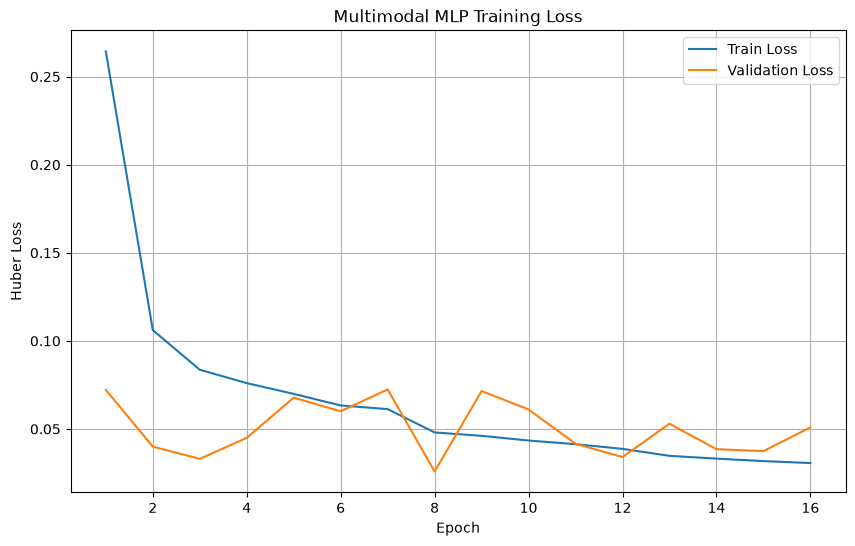

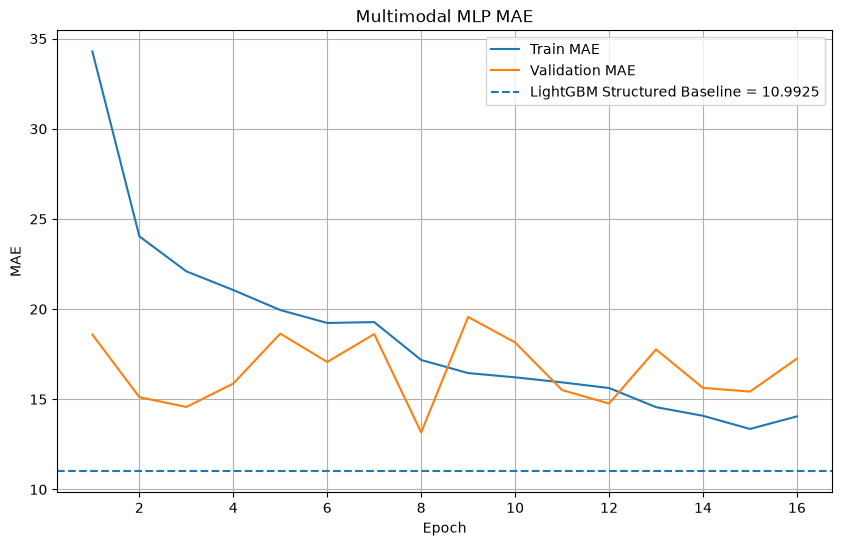


MULTIMODAL MLP TRAINING COMPLETED
Best model: /Users/souravkumar/Downloads/AI-Powered-Smart-Product-Pricing-Visual-Attribute-Extraction-System/models/price_prediction/multimodal_mlp/best_multimodal_mlp.pth
Training history: /Users/souravkumar/Downloads/AI-Powered-Smart-Product-Pricing-Visual-Attribute-Extraction-System/data/reports/price_prediction/multimodal_mlp/training_history.csv
Predictions: /Users/souravkumar/Downloads/AI-Powered-Smart-Product-Pricing-Visual-Attribute-Extraction-System/data/reports/price_prediction/multimodal_mlp/test_predictions.csv
Metrics: /Users/souravkumar/Downloads/AI-Powered-Smart-Product-Pricing-Visual-Attribute-Extraction-System/data/reports/price_prediction/multimodal_mlp/final_metrics.json


In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)
from torch.utils.data import (
    DataLoader,
    Dataset,
)


# ============================================================
# CONFIGURATION
# ============================================================

CURRENT_DIRECTORY = Path.cwd()

PROJECT_ROOT = (
    CURRENT_DIRECTORY.parent
    if CURRENT_DIRECTORY.name.lower() == "notebooks"
    else CURRENT_DIRECTORY
)

MODEL_INPUT_ROOT = (
    PROJECT_ROOT
    / "data"
    / "amazon_multimodal"
    / "model_input"
)

EMBEDDING_ROOT = (
    PROJECT_ROOT
    / "data"
    / "amazon_multimodal"
    / "embeddings"
    / "clip"
)

MODEL_ROOT = (
    PROJECT_ROOT
    / "models"
    / "price_prediction"
    / "multimodal_mlp"
)

REPORT_ROOT = (
    PROJECT_ROOT
    / "data"
    / "reports"
    / "price_prediction"
    / "multimodal_mlp"
)

MODEL_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


BEST_MODEL_FILE = (
    MODEL_ROOT
    / "best_multimodal_mlp.pth"
)

PREPROCESSOR_FILE = (
    MODEL_ROOT
    / "structured_preprocessor.joblib"
)

TRAINING_HISTORY_FILE = (
    REPORT_ROOT
    / "training_history.csv"
)

TEST_PREDICTIONS_FILE = (
    REPORT_ROOT
    / "test_predictions.csv"
)

FINAL_METRICS_FILE = (
    REPORT_ROOT
    / "final_metrics.json"
)

LOSS_CURVE_FILE = (
    REPORT_ROOT
    / "loss_curve.png"
)

MAE_CURVE_FILE = (
    REPORT_ROOT
    / "mae_curve.png"
)


# ============================================================
# HYPERPARAMETERS
# ============================================================

EPOCHS = 50
BATCH_SIZE = 64

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 8

IMAGE_DIM = 512
TEXT_DIM = 512

RANDOM_STATE = 42


# ============================================================
# DEVICE
# ============================================================

torch.manual_seed(
    RANDOM_STATE
)

np.random.seed(
    RANDOM_STATE
)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")

elif (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
):
    DEVICE = torch.device("mps")

else:
    DEVICE = torch.device("cpu")


print("Using device:", DEVICE)


# ============================================================
# LOAD SPLIT
# ============================================================

def load_split(
    split_name: str,
):

    image_embeddings = np.load(
        EMBEDDING_ROOT
        / f"{split_name}_image_embeddings.npy"
    ).astype(np.float32)

    text_embeddings = np.load(
        EMBEDDING_ROOT
        / f"{split_name}_text_embeddings.npy"
    ).astype(np.float32)

    metadata = pd.read_parquet(
        MODEL_INPUT_ROOT
        / f"{split_name}.parquet"
    ).reset_index(drop=True)

    if not (
        len(image_embeddings)
        == len(text_embeddings)
        == len(metadata)
    ):
        raise ValueError(
            f"{split_name} row mismatch"
        )

    return (
        image_embeddings,
        text_embeddings,
        metadata,
    )


# ============================================================
# LOAD DATA
# ============================================================

X_train_image, X_train_text, train_df = (
    load_split("train")
)

X_val_image, X_val_text, validation_df = (
    load_split("validation")
)

X_test_image, X_test_text, test_df = (
    load_split("test")
)

print(
    "Train:",
    X_train_image.shape,
    X_train_text.shape,
    train_df.shape,
)

print(
    "Validation:",
    X_val_image.shape,
    X_val_text.shape,
    validation_df.shape,
)

print(
    "Test:",
    X_test_image.shape,
    X_test_text.shape,
    test_df.shape,
)


# ============================================================
# STRUCTURED FEATURES
# ============================================================

for dataframe in [
    train_df,
    validation_df,
    test_df,
]:

    dataframe["reviews_log1p"] = np.log1p(
        pd.to_numeric(
            dataframe["reviews"],
            errors="coerce",
        ).fillna(0)
    )

    dataframe["bought_log1p"] = np.log1p(
        pd.to_numeric(
            dataframe["boughtInLastMonth"],
            errors="coerce",
        ).fillna(0)
    )


numeric_columns = [
    "stars",
    "reviews_log1p",
    "bought_log1p",
    "isBestSeller",
    "cluster_id",
]

categorical_columns = [
    "category_name",
    "price_band",
]


structured_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_columns,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_columns,
        ),
    ],
    remainder="drop",
)


X_train_structured = (
    structured_preprocessor
    .fit_transform(train_df)
    .astype(np.float32)
)

X_val_structured = (
    structured_preprocessor
    .transform(validation_df)
    .astype(np.float32)
)

X_test_structured = (
    structured_preprocessor
    .transform(test_df)
    .astype(np.float32)
)

joblib.dump(
    structured_preprocessor,
    PREPROCESSOR_FILE,
)

STRUCTURED_DIM = (
    X_train_structured.shape[1]
)

print(
    "Structured feature dimension:",
    STRUCTURED_DIM,
)


# ============================================================
# TARGET
# ============================================================

y_train = (
    train_df["price"]
    .astype(np.float32)
    .to_numpy()
)

y_validation = (
    validation_df["price"]
    .astype(np.float32)
    .to_numpy()
)

y_test = (
    test_df["price"]
    .astype(np.float32)
    .to_numpy()
)


y_train_log = np.log1p(
    y_train
).astype(np.float32)

y_validation_log = np.log1p(
    y_validation
).astype(np.float32)

y_test_log = np.log1p(
    y_test
).astype(np.float32)


# ============================================================
# DATASET
# ============================================================

class MultimodalPriceDataset(
    Dataset
):

    def __init__(
        self,
        image_features,
        text_features,
        structured_features,
        targets,
    ):

        self.image_features = torch.from_numpy(
            image_features
        )

        self.text_features = torch.from_numpy(
            text_features
        )

        self.structured_features = torch.from_numpy(
            structured_features
        )

        self.targets = torch.from_numpy(
            targets
        ).float()

    def __len__(self):
        return len(self.targets)

    def __getitem__(
        self,
        index,
    ):

        return (
            self.image_features[index],
            self.text_features[index],
            self.structured_features[index],
            self.targets[index],
        )


# ============================================================
# DATASETS
# ============================================================

train_dataset = MultimodalPriceDataset(
    X_train_image,
    X_train_text,
    X_train_structured,
    y_train_log,
)

validation_dataset = MultimodalPriceDataset(
    X_val_image,
    X_val_text,
    X_val_structured,
    y_validation_log,
)

test_dataset = MultimodalPriceDataset(
    X_test_image,
    X_test_text,
    X_test_structured,
    y_test_log,
)


# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


# ============================================================
# MODEL
# ============================================================

class MultimodalPriceModel(
    nn.Module
):

    def __init__(
        self,
        image_dim: int,
        text_dim: int,
        structured_dim: int,
    ):

        super().__init__()

        self.image_encoder = nn.Sequential(
            nn.Linear(
                image_dim,
                256,
            ),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(
                256,
                128,
            ),
            nn.ReLU(),
        )

        self.text_encoder = nn.Sequential(
            nn.Linear(
                text_dim,
                256,
            ),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(
                256,
                128,
            ),
            nn.ReLU(),
        )

        self.structured_encoder = nn.Sequential(
            nn.Linear(
                structured_dim,
                128,
            ),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(
                128,
                64,
            ),
            nn.ReLU(),
        )

        fusion_input_dim = (
            128
            + 128
            + 64
        )

        self.fusion = nn.Sequential(
            nn.Linear(
                fusion_input_dim,
                256,
            ),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(
                256,
                128,
            ),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(
                128,
                64,
            ),
            nn.ReLU(),

            nn.Linear(
                64,
                1,
            ),
        )

    def forward(
        self,
        image_features,
        text_features,
        structured_features,
    ):

        image_features = (
            self.image_encoder(
                image_features
            )
        )

        text_features = (
            self.text_encoder(
                text_features
            )
        )

        structured_features = (
            self.structured_encoder(
                structured_features
            )
        )

        fused_features = torch.cat(
            [
                image_features,
                text_features,
                structured_features,
            ],
            dim=1,
        )

        output = self.fusion(
            fused_features
        )

        return output.squeeze(1)


# ============================================================
# INITIALIZE MODEL
# ============================================================

model = MultimodalPriceModel(
    image_dim=IMAGE_DIM,
    text_dim=TEXT_DIM,
    structured_dim=STRUCTURED_DIM,
)

model = model.to(
    DEVICE
)

print(model)


# ============================================================
# LOSS
# ============================================================

loss_function = nn.HuberLoss(
    delta=1.0
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


# ============================================================
# LR SCHEDULER
# ============================================================

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    )
)


# ============================================================
# METRICS
# ============================================================

def calculate_metrics(
    actual_log,
    predicted_log,
):

    actual_price = np.expm1(
        actual_log
    )

    predicted_price = np.expm1(
        predicted_log
    )

    predicted_price = np.clip(
        predicted_price,
        0,
        None,
    )

    mae = mean_absolute_error(
        actual_price,
        predicted_price,
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_price,
            predicted_price,
        )
    )

    median_ae = (
        median_absolute_error(
            actual_price,
            predicted_price,
        )
    )

    r2 = r2_score(
        actual_price,
        predicted_price,
    )

    return {
        "mae": mae,
        "rmse": rmse,
        "median_ae": median_ae,
        "r2": r2,
    }


# ============================================================
# TRAIN ONE EPOCH
# ============================================================

def train_one_epoch():

    model.train()

    running_loss = 0.0

    predictions = []
    targets = []

    for (
        image_features,
        text_features,
        structured_features,
        target,
    ) in train_loader:

        image_features = (
            image_features.to(
                DEVICE
            )
        )

        text_features = (
            text_features.to(
                DEVICE
            )
        )

        structured_features = (
            structured_features.to(
                DEVICE
            )
        )

        target = target.to(
            DEVICE
        )

        optimizer.zero_grad()

        prediction = model(
            image_features,
            text_features,
            structured_features,
        )

        loss = loss_function(
            prediction,
            target,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        running_loss += (
            loss.item()
            * len(target)
        )

        predictions.append(
            prediction
            .detach()
            .cpu()
            .numpy()
        )

        targets.append(
            target
            .detach()
            .cpu()
            .numpy()
        )

    predictions = np.concatenate(
        predictions
    )

    targets = np.concatenate(
        targets
    )

    average_loss = (
        running_loss
        / len(train_dataset)
    )

    metrics = calculate_metrics(
        targets,
        predictions,
    )

    return (
        average_loss,
        metrics,
    )


# ============================================================
# VALIDATION
# ============================================================

def evaluate_loader(
    loader,
    dataset,
):

    model.eval()

    running_loss = 0.0

    predictions = []
    targets = []

    with torch.inference_mode():

        for (
            image_features,
            text_features,
            structured_features,
            target,
        ) in loader:

            image_features = (
                image_features.to(
                    DEVICE
                )
            )

            text_features = (
                text_features.to(
                    DEVICE
                )
            )

            structured_features = (
                structured_features.to(
                    DEVICE
                )
            )

            target = target.to(
                DEVICE
            )

            prediction = model(
                image_features,
                text_features,
                structured_features,
            )

            loss = loss_function(
                prediction,
                target,
            )

            running_loss += (
                loss.item()
                * len(target)
            )

            predictions.append(
                prediction
                .cpu()
                .numpy()
            )

            targets.append(
                target
                .cpu()
                .numpy()
            )

    predictions = np.concatenate(
        predictions
    )

    targets = np.concatenate(
        targets
    )

    average_loss = (
        running_loss
        / len(dataset)
    )

    metrics = calculate_metrics(
        targets,
        predictions,
    )

    return (
        average_loss,
        metrics,
        targets,
        predictions,
    )


# ============================================================
# TRAINING LOOP
# ============================================================

history = []

best_validation_mae = float(
    "inf"
)

epochs_without_improvement = 0


print()
print("=" * 100)
print("MULTIMODAL MLP TRAINING")
print("=" * 100)


for epoch in range(
    1,
    EPOCHS + 1,
):

    train_loss, train_metrics = (
        train_one_epoch()
    )

    (
        validation_loss,
        validation_metrics,
        _,
        _,
    ) = evaluate_loader(
        validation_loader,
        validation_dataset,
    )

    scheduler.step(
        validation_loss
    )

    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )

    history.append(
        {
            "epoch": epoch,

            "train_loss":
                train_loss,

            "validation_loss":
                validation_loss,

            "train_mae":
                train_metrics["mae"],

            "validation_mae":
                validation_metrics["mae"],

            "train_rmse":
                train_metrics["rmse"],

            "validation_rmse":
                validation_metrics[
                    "rmse"
                ],

            "train_r2":
                train_metrics["r2"],

            "validation_r2":
                validation_metrics[
                    "r2"
                ],

            "learning_rate":
                current_lr,
        }
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {validation_loss:.4f} | "
        f"Train MAE: {train_metrics['mae']:.4f} | "
        f"Val MAE: {validation_metrics['mae']:.4f} | "
        f"Val RMSE: {validation_metrics['rmse']:.4f} | "
        f"Val R²: {validation_metrics['r2']:.4f} | "
        f"LR: {current_lr:.6f}"
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if (
        validation_metrics["mae"]
        < best_validation_mae
    ):

        best_validation_mae = (
            validation_metrics["mae"]
        )

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "validation_mae":
                    best_validation_mae,

                "structured_dim":
                    STRUCTURED_DIM,

                "image_dim":
                    IMAGE_DIM,

                "text_dim":
                    TEXT_DIM,
            },
            BEST_MODEL_FILE,
        )

        print(
            f"  ✅ Best model saved "
            f"(Val MAE: "
            f"{best_validation_mae:.4f})"
        )

    else:

        epochs_without_improvement += 1


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print()
        print(
            "Early stopping triggered."
        )

        break


# ============================================================
# SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    TRAINING_HISTORY_FILE,
    index=False,
)


# ============================================================
# LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_FILE,
    map_location=DEVICE,
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model.eval()


print()
print(
    "Best validation MAE:",
    checkpoint[
        "validation_mae"
    ],
)

print(
    "Best epoch:",
    checkpoint[
        "epoch"
    ],
)


# ============================================================
# FINAL TEST EVALUATION
# ============================================================

(
    test_loss,
    test_metrics,
    test_targets_log,
    test_predictions_log,
) = evaluate_loader(
    test_loader,
    test_dataset,
)


print()
print("=" * 80)
print("FINAL TEST RESULTS")
print("=" * 80)

print(
    "Test Loss:",
    round(
        test_loss,
        4,
    ),
)

print(
    "MAE:",
    round(
        test_metrics["mae"],
        4,
    ),
)

print(
    "RMSE:",
    round(
        test_metrics["rmse"],
        4,
    ),
)

print(
    "Median AE:",
    round(
        test_metrics[
            "median_ae"
        ],
        4,
    ),
)

print(
    "R²:",
    round(
        test_metrics["r2"],
        4,
    ),
)


# ============================================================
# SAVE TEST PREDICTIONS
# ============================================================

actual_prices = np.expm1(
    test_targets_log
)

predicted_prices = np.expm1(
    test_predictions_log
)

predicted_prices = np.clip(
    predicted_prices,
    0,
    None,
)


prediction_df = test_df[
    [
        "asin",
        "title",
        "category_name",
        "price",
        "price_band",
        "cluster_id",
    ]
].copy()


prediction_df[
    "predicted_price"
] = predicted_prices

prediction_df[
    "absolute_error"
] = np.abs(
    actual_prices
    - predicted_prices
)


prediction_df.to_csv(
    TEST_PREDICTIONS_FILE,
    index=False,
)


# ============================================================
# SAVE FINAL METRICS
# ============================================================

final_metrics = {
    "best_epoch": int(
        checkpoint["epoch"]
    ),

    "best_validation_mae": float(
        checkpoint[
            "validation_mae"
        ]
    ),

    "test_mae": float(
        test_metrics["mae"]
    ),

    "test_rmse": float(
        test_metrics["rmse"]
    ),

    "test_median_absolute_error": float(
        test_metrics[
            "median_ae"
        ]
    ),

    "test_r2": float(
        test_metrics["r2"]
    ),
}


with FINAL_METRICS_FILE.open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        final_metrics,
        file,
        indent=2,
    )


# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss",
)

plt.plot(
    history_df["epoch"],
    history_df[
        "validation_loss"
    ],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title(
    "Multimodal MLP Training Loss"
)

plt.legend()
plt.grid(True)

plt.savefig(
    LOSS_CURVE_FILE,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# MAE CURVE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_mae"],
    label="Train MAE",
)

plt.plot(
    history_df["epoch"],
    history_df[
        "validation_mae"
    ],
    label="Validation MAE",
)

plt.axhline(
    y=10.9925,
    linestyle="--",
    label=(
        "LightGBM Structured "
        "Baseline = 10.9925"
    ),
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title(
    "Multimodal MLP MAE"
)

plt.legend()
plt.grid(True)

plt.savefig(
    MAE_CURVE_FILE,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


print()
print("=" * 100)
print("MULTIMODAL MLP TRAINING COMPLETED")
print("=" * 100)

print(
    "Best model:",
    BEST_MODEL_FILE,
)

print(
    "Training history:",
    TRAINING_HISTORY_FILE,
)

print(
    "Predictions:",
    TEST_PREDICTIONS_FILE,
)

print(
    "Metrics:",
    FINAL_METRICS_FILE,
)